In [1]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from pandas import Series
import numpy as np
from scipy.io import loadmat
import sys
sys.path.append(".")
from lassonet import LassoNetClassifier

In [2]:
# 加载数据
mnist = loadmat('../data/Mnist/mnist-original.mat')

X = mnist['data'].T               #这个一定要转置一下，因为这里面的行列是反的！！！！！
X = X / 255.
y = mnist['label'].T.flatten()     #将数据展开
y= Series(y.astype(np.uint8))              #将格式变为uint8

filter = y.isin([1, 9])
X = X[filter]
y = LabelEncoder().fit_transform(y[filter])

In [3]:
# 分割数据集
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [4]:
# 模型训练
model = LassoNetClassifier(M=30, verbose=2, path_multiplier=1.05, lambda_start=0.2)
path = model.path(X_train, y_train)

Initialized dense model
251 epochs, val_objective 1.48e-02, val_loss 1.48e-02, regularization 2.84e+01, l2_regularization 1.84e+00
Lambda = 0.2, selected 784 features 
100 epochs, val_objective 2.93e+00, val_loss 1.46e-02, regularization 1.46e+01, l2_regularization 1.84e+00
Lambda = 0.21000000000000002, selected 784 features 
100 epochs, val_objective 1.33e+00, val_loss 1.44e-02, regularization 6.27e+00, l2_regularization 1.85e+00
Lambda = 0.22050000000000003, selected 784 features 
100 epochs, val_objective 8.93e-01, val_loss 1.43e-02, regularization 3.99e+00, l2_regularization 1.87e+00
Lambda = 0.23152500000000004, selected 784 features 
100 epochs, val_objective 7.84e-01, val_loss 1.42e-02, regularization 3.33e+00, l2_regularization 1.88e+00
Lambda = 0.24310125000000005, selected 784 features 
66 epochs, val_objective 7.65e-01, val_loss 1.42e-02, regularization 3.09e+00, l2_regularization 1.89e+00
Lambda = 0.2552563125000001, selected 784 features 
10 epochs, val_objective 7.96e-01,

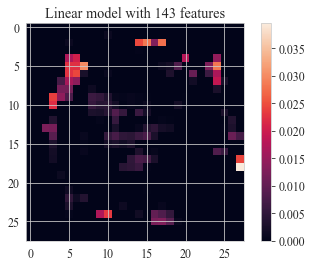

In [13]:
import torch
from matplotlib import rcParams
index = -75

weight = path[index].state_dict["skip.weight"]
importances = torch.norm(weight, p=2, dim=0) / torch.sum(torch.norm(weight, p=2, dim=0))

num = sum(path[index].selected)
config = {
    "font.family": 'Times New Roman',
    "font.size": 12
}
rcParams.update(config)
plt.clf()
plt.title(f"Linear model with {num} features")

img = (importances).reshape(28, 28).T
plt.imshow(img)
plt.colorbar()
plt.savefig("figures/mnist_lassonet_selected.pdf")
plt.show()

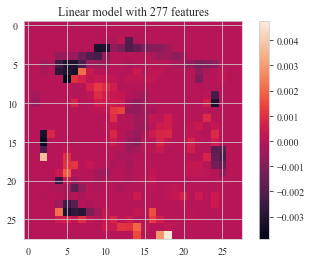

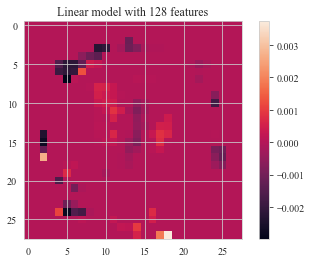

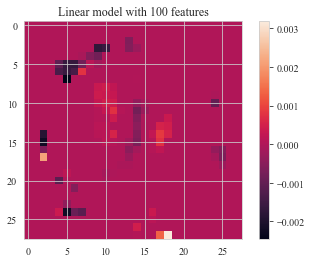

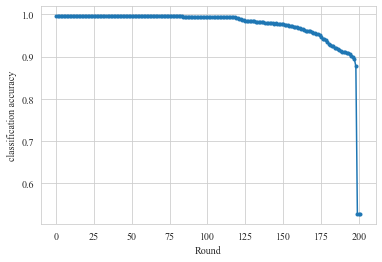

In [6]:
n_selected = []
accuracy = []
lambda_ = []

for save in path:
    model.load(save.state_dict)
    y_pred = model.predict(X_test)
    n_selected.append(save.selected.sum())
    accuracy.append(accuracy_score(y_test, y_pred))
    lambda_.append(save.lambda_)

to_plot = [100, 140, 300]

for i, save in zip(n_selected, path):
    if not to_plot:
        break
    if i > to_plot[-1]:
        continue
    to_plot.pop()
    plt.clf()
    plt.title(f"Linear model with {i} features")
    weight = save.state_dict["skip.weight"]
    img = (weight[1] - weight[0]).reshape(28, 28)
    plt.imshow(img)
    plt.colorbar()
    plt.show()

plt.plot( accuracy, ".-")
plt.xlabel("Round")
plt.ylabel("classification accuracy")
plt.show()